<a href="https://colab.research.google.com/github/Himanshu0518/Traffic-demand-prediction/blob/main/notebooks/01_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv('/content/train.csv')
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57366 entries, 0 to 57365
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          57366 non-null  int64  
 1   geohash        57366 non-null  object 
 2   day            57366 non-null  int64  
 3   timestamp      57366 non-null  object 
 4   demand         57366 non-null  float64
 5   RoadType       56921 non-null  object 
 6   NumberofLanes  57366 non-null  int64  
 7   LargeVehicles  57366 non-null  object 
 8   Landmarks      57366 non-null  object 
 9   Temperature    55513 non-null  float64
 10  Weather        56773 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 4.8+ MB


In [27]:
df.isnull().sum()

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,445
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,1853


In [28]:
df['Weather'].value_counts()

,count
Weather,
Sunny,20623
Rainy,15399
Foggy,15006
Snowy,5745


In [29]:
df.shape

(57366, 11)

In [40]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class DateFeatureExtractor(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        X = X.copy()

        # Combine 'day' and 'timestamp' to create a full datetime.
        # Assuming 'day' is a day of the year (1-365/366) and 'timestamp' is 'HH:MM'.
        # We use a dummy year (e.g., 2000) for parsing.
        full_datetime_series = pd.to_datetime(
            '2000-' + X['day'].astype(str) + ' ' + X['timestamp'],
            format='%Y-%j %H:%M'
        )

        X['hour'] = full_datetime_series.dt.hour
        X['dayofweek'] = full_datetime_series.dt.dayofweek
        X['month'] = full_datetime_series.dt.month

        X['is_weekend'] = (
            X['dayofweek'] >= 5
        ).astype(int)

        # cyclical encoding
        X['hour_sin'] = np.sin(2*np.pi*X['hour']/24)
        X['hour_cos'] = np.cos(2*np.pi*X['hour']/24)

        # Drop original 'timestamp' and 'day' columns as their information is extracted
        X = X.drop(columns=['timestamp', 'day'])

        return X

# Data Visualization

<Axes: xlabel='NumberofLanes', ylabel='demand'>

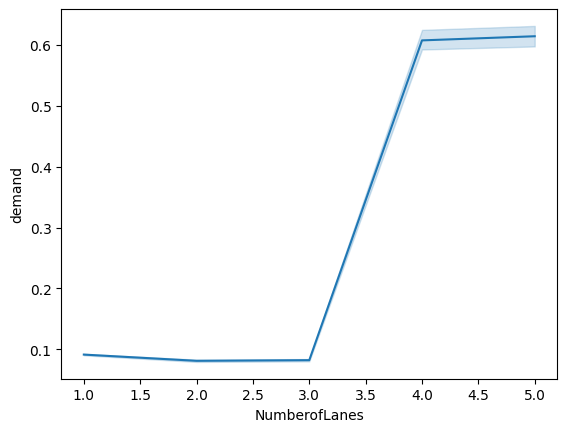

In [54]:
sns.lineplot(data=df, x='NumberofLanes', y='demand')

### Further Data Exploration

In [55]:
# Apply DateFeatureExtractor to the DataFrame for visualization
df_viz = df.copy()
date_extractor = DateFeatureExtractor()
df_viz = date_extractor.transform(df_viz)

# Display the first few rows of the transformed DataFrame to confirm new features
print("DataFrame with extracted date features:")
display(df_viz.head())

DataFrame with extracted date features:


,Index,geohash,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour,dayofweek,month,is_weekend,hour_sin,hour_cos
0,0,qp02z1,0.048804,NaN,1,Not Allowed,No,NaN,NaN,0,3,2,0,0.0,1.0
1,1,qp02zt,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,3,2,0,0.0,1.0
2,2,qp08bj,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,3,2,0,0.0,1.0
3,3,qp08gt,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,0,3,2,0,0.0,1.0
4,4,qp02zq,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,3,2,0,0.0,1.0


### Average Demand by Hour of the Day

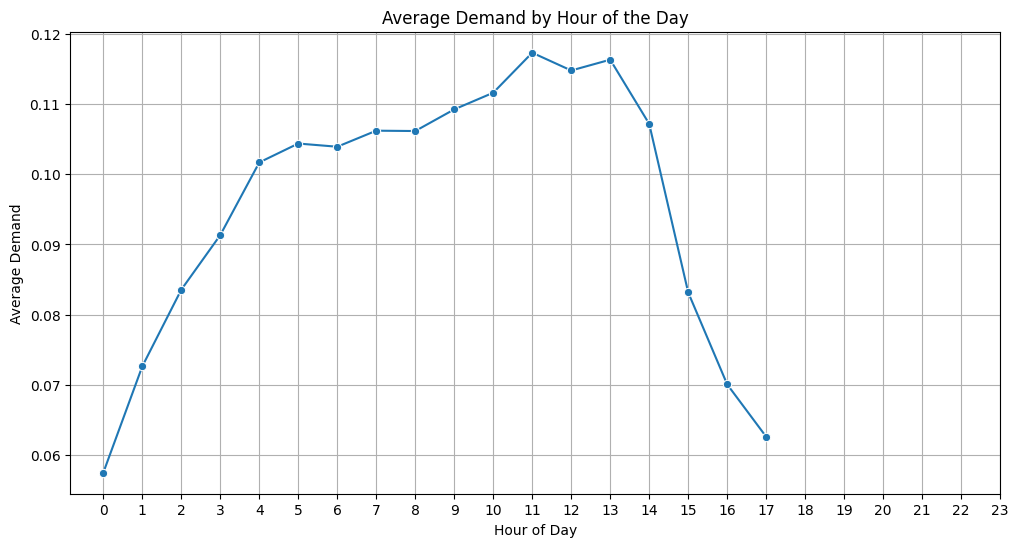

In [56]:
avg_demand_by_hour = df_viz.groupby('hour')['demand'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='hour', y='demand', data=avg_demand_by_hour, marker='o')
plt.title('Average Demand by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.grid(True)
plt.xticks(range(0, 24))
plt.show()

### Average Demand by Day of the Week

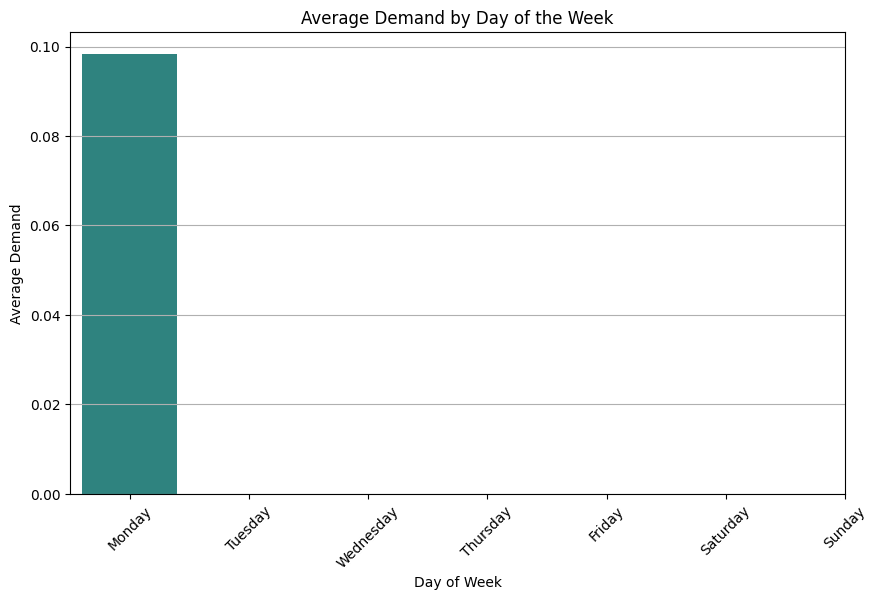

In [57]:
avg_demand_by_dayofweek = df_viz.groupby('dayofweek')['demand'].mean().reset_index()

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10, 6))
sns.barplot(x='dayofweek', y='demand', data=avg_demand_by_dayofweek, palette='viridis')
plt.title('Average Demand by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand')
plt.xticks(ticks=range(7), labels=day_names, rotation=45)
plt.grid(axis='y')
plt.show()

In [61]:
df['day'].value_counts()

,count
day,
48,57366


### Average Demand by RoadType

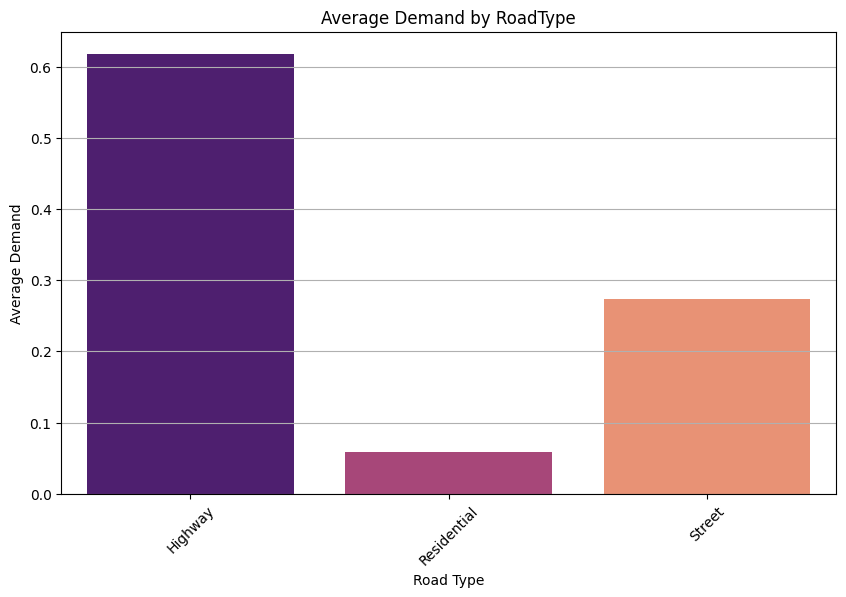

In [58]:
avg_demand_by_roadtype = df_viz.groupby('RoadType')['demand'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='RoadType', y='demand', data=avg_demand_by_roadtype, palette='magma')
plt.title('Average Demand by RoadType')
plt.xlabel('Road Type')
plt.ylabel('Average Demand')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### Average Demand by Weather

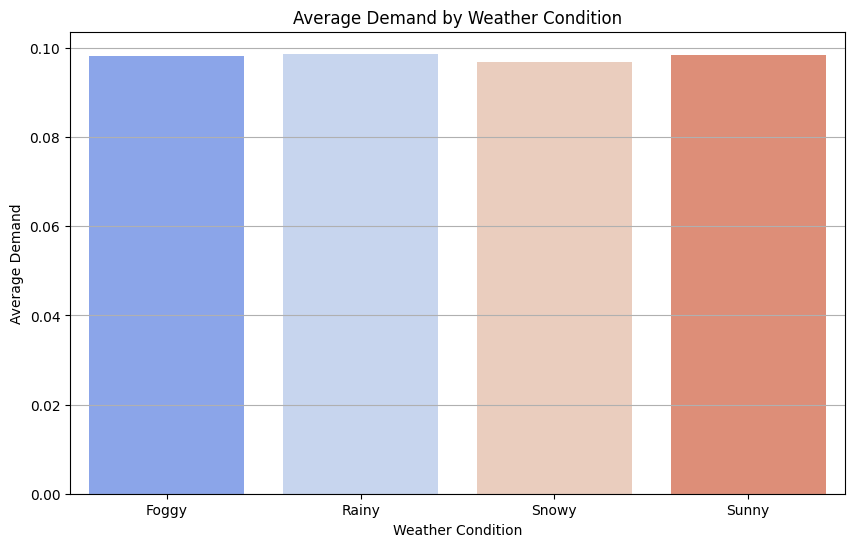

In [59]:
avg_demand_by_weather = df_viz.groupby('Weather')['demand'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Weather', y='demand', data=avg_demand_by_weather, palette='coolwarm')
plt.title('Average Demand by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Demand')
plt.grid(axis='y')
plt.show()

### Average Demand by LargeVehicles

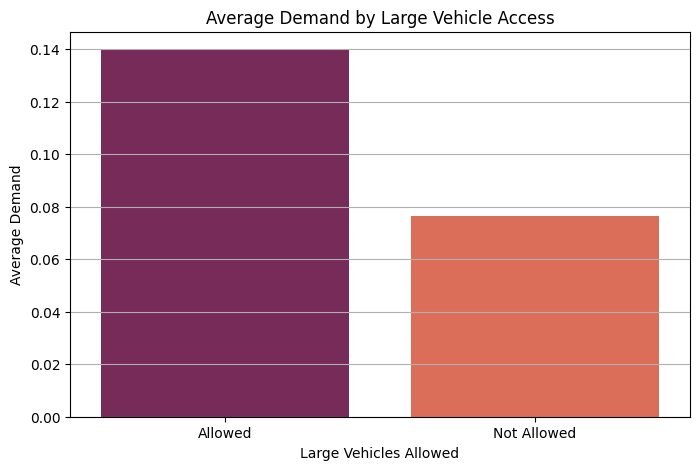

In [60]:
avg_demand_by_largevehicles = df_viz.groupby('LargeVehicles')['demand'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='LargeVehicles', y='demand', data=avg_demand_by_largevehicles, palette='rocket')
plt.title('Average Demand by Large Vehicle Access')
plt.xlabel('Large Vehicles Allowed')
plt.ylabel('Average Demand')
plt.grid(axis='y')
plt.show()

# Model Trainning pipeline

In [31]:
categorical_cols = [
    'geohash',
    'RoadType',
    'Weather',
    'Landmarks',
    'LargeVehicles'
]

numerical_cols = [
    'Temperature',
    'NumberofLanes',
    'hour',
    'dayofweek',
    'month',
    'is_weekend',
    'hour_sin',
    'hour_cos'
]

In [32]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [33]:
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

In [34]:
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

In [52]:
!#pip install catboost

In [35]:
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

In [36]:


pipeline = Pipeline([
    ('date_features', DateFeatureExtractor()),
    ('preprocessor', preprocessor),
    ('model', LGBMRegressor())
])

In [49]:
algorithms = [
     CatBoostRegressor(),
     LGBMRegressor(
      random_state=42
 )
]

In [50]:
# Split data into features (X) and target (y)
X = df.drop('demand', axis=1)
y = df['demand']

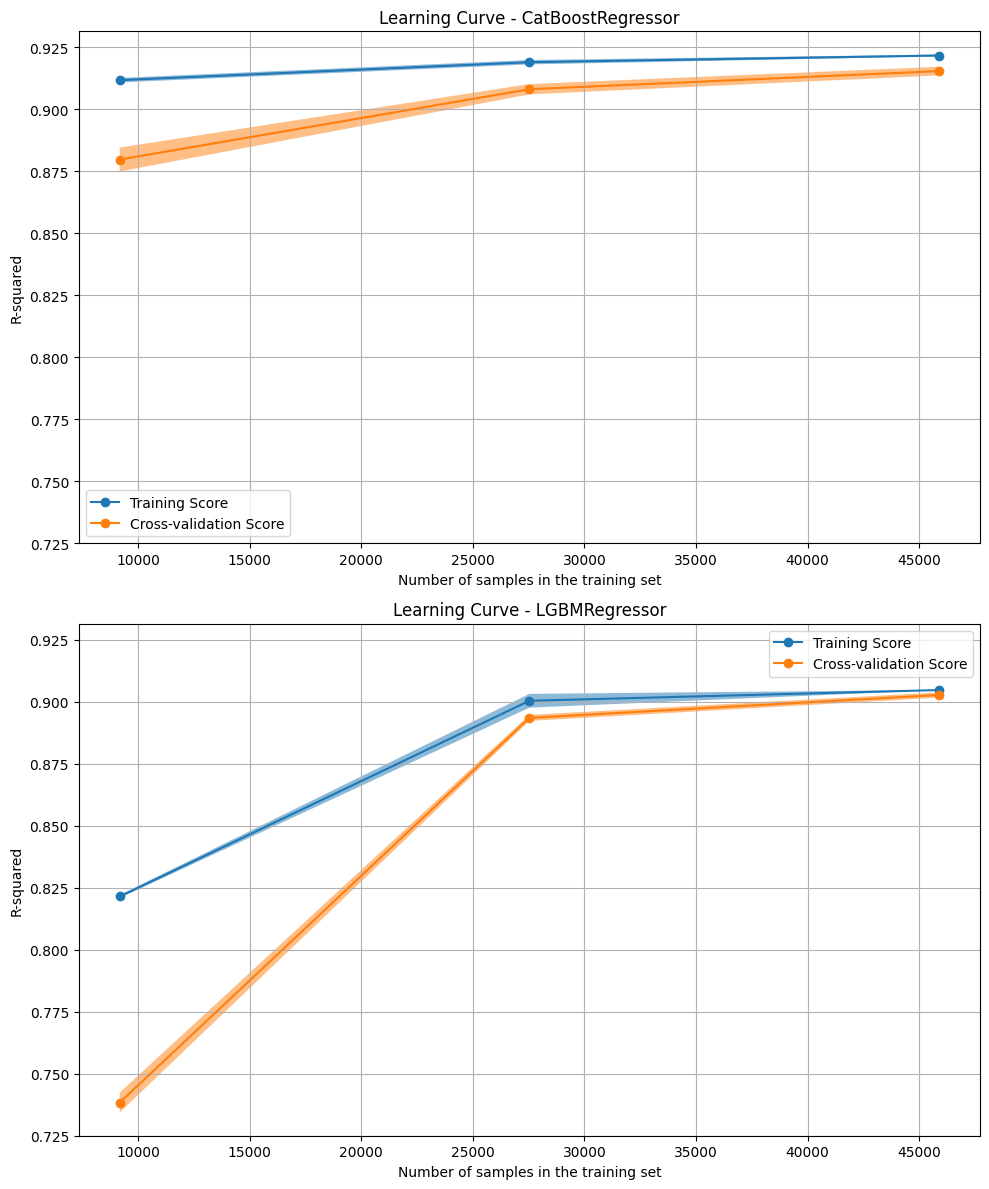

In [51]:
num_algorithms = len(algorithms)

fig, axes = plt.subplots(
    nrows=num_algorithms,
    ncols=1,
    figsize=(10, 6 * num_algorithms),
    sharey=True
)

# If only one algorithm, convert axes to list
if num_algorithms == 1:
    axes = [axes]

common_params = {
    "X": X,
    "y": y, # Changed Y to y
    "train_sizes": np.linspace(0.2, 1.0, 3),
    "cv": ShuffleSplit(n_splits=3, test_size=0.2, random_state=0),
    "score_type": "both",
    "n_jobs": -1,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "R-squared", # Changed score_name to R-squared for regression
    "scoring": "r2" # Added scoring parameter for R-squared
}

for ax, model_algo in zip(axes, algorithms):

    pipeline_estimator = Pipeline([
        ('date_features', DateFeatureExtractor()), # Added DateFeatureExtractor
        ('preprocessor', preprocessor),
        ('regressor', model_algo) # Changed classifier to regressor
    ])

    LearningCurveDisplay.from_estimator(
        pipeline_estimator,
        **common_params,
        ax=ax
    )

    handles, labels = ax.get_legend_handles_labels()

    ax.legend(
        handles[:2],
        ["Training Score", "Cross-validation Score"]
    )

    ax.set_title(
        f"Learning Curve - {model_algo.__class__.__name__}"
    )

    ax.grid(True)

plt.tight_layout()
plt.show()